In [1]:
import sys
import time
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import scipy.constants as sc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()

import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm);

tau = 2566.2 s | t_horizon/tau = 1.40 | jn_tilde = -0.208549


Text(0, 0.5, 'Molar flux [mol/m$^2$/s]')

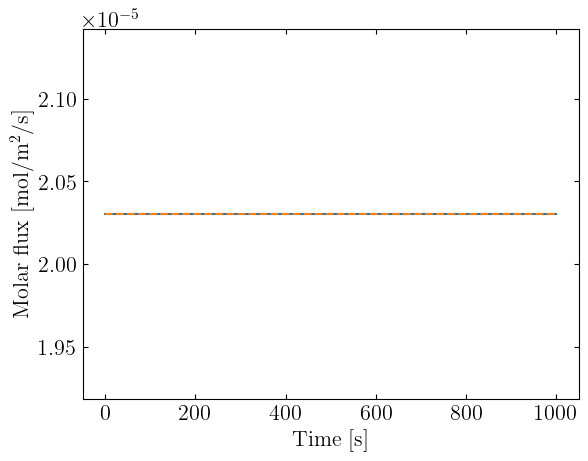

In [94]:
# Parameters
I = 1  # Current in A
sol, model0, params = sim_PyBaMM.simulate_DC1(I0=I, T=1000, T_horizon=3600)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
I_vals = sol.observe(model0.variables['Current [A]'])(t)
Dn = sol.observe(model0.variables['X-averaged negative particle effective diffusivity [m2.s-1]'])(t)[-1,0]
c_surf = sol.observe(model0.variables['X-averaged negative particle surface concentration [mol.m-3]'])(t)
c_true = sol.observe(model0.variables['Negative particle concentration [mol.m-3]'])(t)
c0 = params['Initial concentration in negative electrode [mol.m-3]']
cn_max = params['Maximum concentration in negative electrode [mol.m-3]']
Ln = params['Negative electrode thickness [m]']
A = params['Electrode height [m]'] * params['Electrode width [m]']
Rn = params['Negative particle radius [m]']
en = params['Negative electrode active material volume fraction']
an = 3 * en / Rn

F = sc.physical_constants['Faraday constant'][0]


# Non-dimensionalization
tau = Rn**2 / Dn  # Time scale
c0_tilde = c0 / cn_max
jn = I / (F*an*A*Ln) # molar flux mol / m^2s    At the surface
jn_tilde = - jn * Rn / (Dn * cn_max)  # non-dimensional flux

t_horizon = 3600
t_tilde_max = t_horizon / tau           # how far in t̃ we need to go
print(f"tau = {tau:.1f} s | t_horizon/tau = {t_tilde_max:.2f} | jn_tilde = {jn_tilde:.6f}")



# def j(c_surf,params, which_c = 'n'):
#     ce = params['Initial concentration in electrolyte [mol.m-3]']
#     kn=2e-5;kp=6e-7
#     F = sc.physical_constants['Faraday constant'][0]
#     R = sc.R
#     T = params['Initial temperature [K]']

#     if which_c == 'n':
#         cmax = params['Maximum concentration in negative electrode [mol.m-3]']
#         k = kn
#     elif which_c == 'p':
#         cmax = params['Maximum concentration in positive electrode [mol.m-3]']
#         k = kp
#     else:
#         raise ValueError('which_c must be either "n" or "p"')
#     j0 = k * np.sqrt(ce * c_surf * (cmax-c_surf)) 

#     return j0

# jn_true = j(c_surf, params, which_c='n')

jn_true_bamm = np.mean(sol.observe(model0.variables['X-averaged negative particle flux [mol.m-2.s-1]'])(t), axis=0)
jn_true_bamm = sol.observe(model0.variables['X-averaged negative particle flux [mol.m-2.s-1]'])(t)[-1,:]
# jn_true_bamm = np.mean(sol.observe(model0.variables['X-averaged negative electrode total interfacial current density [A.m-2]'])(t), axis=0)
# jn = np.ones_like(jn_true)*jn

plt.plot(np.ones_like(I_vals)*jn)
plt.plot(jn_true_bamm, '--', label='PyBaMM')
plt.xlabel('Time [s]')
plt.ylabel('Molar flux [mol/m$^2$/s]')




In [107]:
class Net(nn.Module):
    def __init__(self, input_size=2, hidden_size=128):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x):
        t_tilde = x[:, 0:1]  # (N, 1)
        raw = self.net(x)
        # Hard coded c(r, 0) = c0, instead of ic_loss
        return raw * t_tilde + c0_tilde  # c = NN(r, t) * t + c0
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )[0]

# def ic_loss(model):
#     # Initial condition u(r, 0) = c0
#     c0 = c0_tilde
#     r_ic = torch.linspace(0, 1, 100).reshape(-1, 1)
#     t_ic = torch.zeros(100, 1)
    
#     tr_ic = torch.cat([t_ic, r_ic], dim=1)
#     u_ic = model(tr_ic)
#     return torch.mean((u_ic - c0)**2)

def bc_loss(model, t_tilde_max):
    # r=0: du/dr = 0
    t_bc = torch.linspace(0, t_tilde_max, 200).reshape(-1, 1)  # (100, 1)
    r0 = torch.zeros(200, 1).requires_grad_(True)  # r=0 boundary
    u_r0 = model(torch.cat([t_bc, r0], dim=1))
    du_dr0 = grad(u_r0, r0)
    bc_0 = torch.mean(du_dr0**2)

    # r = R: du/dr = flux
    rR = torch.ones(200, 1).requires_grad_(True)  # r=R boundary
    u_rR = model(torch.cat([t_bc, rR], dim=1))
    du_drR = grad(u_rR, rR)
    bc_R = torch.mean((du_drR - jn_tilde)**2)
    
    return bc_0 + bc_R

def physics_loss(model, T, R):
    y_pred = model(torch.cat([T, R], dim=1))
    # compute du/dt du/dr
    du_dt = grad(y_pred, T)
    du_dr = grad(y_pred, R)
    d2u_dr2 = grad(du_dr, R)

    pde = du_dt * R - (2 * du_dr + R * d2u_dr2) # dimensionless
    return torch.mean(pde**2)

In [108]:
# Collocation points in dimensionless form
t_1d = torch.linspace(0, t_horizon/tau, 1000)
r_1d = torch.linspace(0, 1, 50)
T_col, R_col = torch.meshgrid(t_1d, r_1d, indexing='ij')  # each (100, 100)
T_col = T_col.reshape(-1, 1).requires_grad_(True)          # (10000, 1)
R_col = R_col.reshape(-1, 1).requires_grad_(True)          # (10000, 1)
TR_col = torch.cat([T_col, R_col], dim=1)                      # (10000, 2)

def training(epochs=50, tol=2.5e-4, model=model, optimizer=optimizer):
    history = {'loss': [], 'p_loss': [], 'b_loss': []}
    model.train()
    
    for epoch in range(epochs):
        p_loss = physics_loss(model, T_col, R_col)
        b_loss = bc_loss(model, t_tilde_max)
        loss = p_loss + 10 * b_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history['loss'].append(loss.item())
        history['p_loss'].append(p_loss.item())
        history['b_loss'].append(b_loss.item())

        if epoch % 100 == 0:
            print(f'Epoch {epoch+1} loss: {p_loss:.5f}')

    return model, history

In [109]:
model, history = training(epochs=250, model=model, optimizer=optimizer)

Epoch 1 loss: 0.03195
Epoch 101 loss: 0.00285
Epoch 201 loss: 0.00159


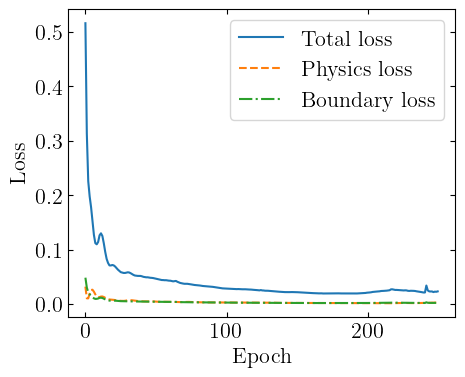

In [110]:
plt.figure(figsize=(5,4))
plt.plot(history['loss'],   label='Total loss')
plt.plot(history['p_loss'], label='Physics loss', linestyle='--')
plt.plot(history['b_loss'], label='Boundary loss', linestyle='-.')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

(200, 50)


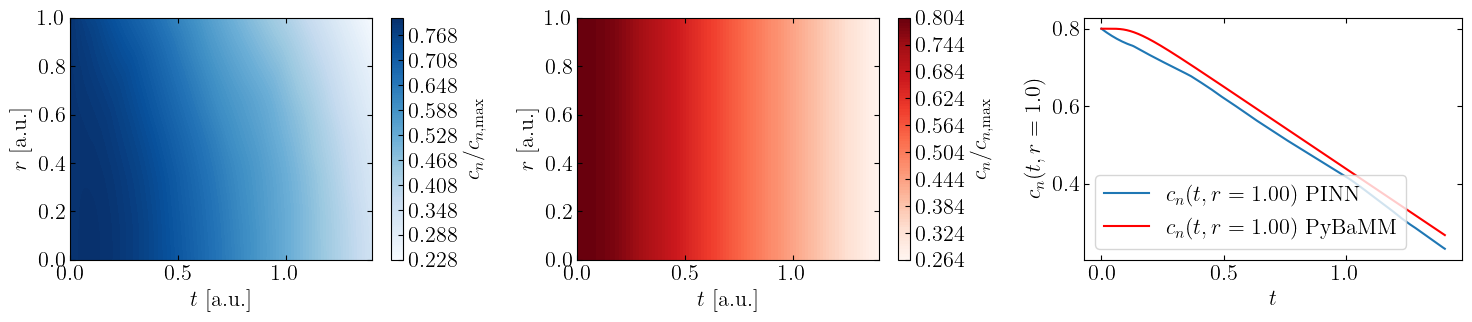

In [115]:
model.eval()
t_num, r_num = 200, 50
t_tilde_vals = torch.linspace(0, t_tilde_max, t_num)  # full dimensionless range
r_tilde_vals = torch.linspace(0, 1, r_num)

T_mesh, R_mesh = torch.meshgrid(t_tilde_vals, r_tilde_vals, indexing='ij')
TR_test = torch.cat([T_mesh.reshape(-1,1), R_mesh.reshape(-1,1)], dim=1)

pred = model(TR_test).detach().numpy().reshape(t_num, r_num) # Shape (1000, 1000) = (t_index, r_index)
print(pred.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].contourf(T_mesh.detach().numpy(), R_mesh.detach().numpy(), pred, levels=100, cmap='Blues')
axes[0].set_xlabel('$t$ [a.u.]')
axes[0].set_ylabel('$r$ [a.u.]')
cb = plt.colorbar(axes[0].collections[0], ax=axes[0], label='$c_n/c_{n, \max}$')



# Plot true
t_num, r_num = 1000, 20
t_tilde_vals_true = torch.linspace(0, t_tilde_max, t_num)  # full dimensionless range
r_tilde_vals_true = torch.linspace(0, 1, r_num)

T_mesh, R_mesh = torch.meshgrid(t_tilde_vals_true, r_tilde_vals_true, indexing='ij')

axes[1].contourf(T_mesh.detach().numpy(), R_mesh.detach().numpy(), c_true[0, :, :].T/cn_max, levels=100, cmap='Reds')
axes[1].set_xlabel('$t$ [a.u.]')
axes[1].set_ylabel('$r$ [a.u.]')
cb = plt.colorbar(axes[1].collections[0], ax=axes[1], label='$c_n/c_{n, \max}$')

# Fixed r plot u(t)
r_target = 1
r_idx_pred = torch.argmin(torch.abs(r_tilde_vals - r_target)).item()

axes[2].plot(t_tilde_vals.numpy(), pred[:, r_idx_pred], label=f'$c_n(t, r={r_tilde_vals[r_idx_pred]:.2f})$ PINN')
axes[2].set_xlabel('t')

# Fixed r plot u(t)
r_target = 1
r_idx = torch.argmin(torch.abs(r_tilde_vals_true - r_target)).item()

axes[2].plot(t_tilde_vals_true.numpy(), c_true[0, r_idx, :]/cn_max, color='red', label=f'$c_n(t, r={r_tilde_vals_true[r_idx]:.2f})$ PyBaMM')
axes[2].set_xlabel('$t$')
axes[2].set_ylabel(f'$c_n(t, r={1.0})$')
axes[2].legend()

fig.tight_layout()


Relative L2 error: nan


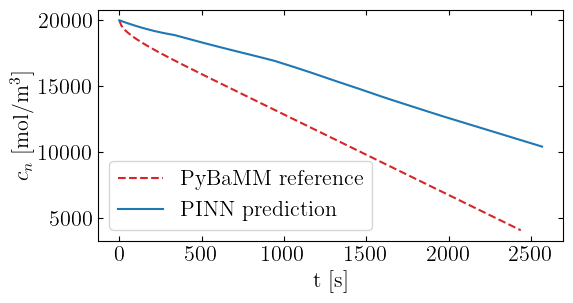

In [112]:
# --- 1. Predict in dimensionless domain ---
t_num, r_num = 200, 50
t_tilde_vals = torch.linspace(0, 1, t_num)          # t̃ ∈ [0, 1]
r_tilde_vals = torch.linspace(0, 1, r_num)          # r̃ ∈ [0, 1]

T_mesh, R_mesh = torch.meshgrid(t_tilde_vals, r_tilde_vals, indexing='ij')
TR_test = torch.cat([T_mesh.reshape(-1,1), R_mesh.reshape(-1,1)], dim=1)

c_tilde_pred = model(TR_test).detach().numpy().reshape(t_num, r_num)

# --- 2. Convert back to physical dimensions ---
t_phys = t_tilde_vals.numpy() * tau                 # t̃ → t [s]
r_phys = r_tilde_vals.numpy() * Rn                  # r̃ → r [m]
c_phys_pred = c_tilde_pred * cn_max                 # c̃ → c [mol/m^3]

# --- 3. Get PyBaMM reference in physical dimensions ---
t_ref = t_phys  # same time points
c_surf_pybamm = sol['X-averaged negative particle surface concentration [mol.m-3]'](t_ref)

# --- 4. Compare surface concentration (r̃ = 1, last r index) ---
c_surf_pinn = c_phys_pred[:, -1]                    # r̃=1 → r=Rn (surface)

plt.figure(figsize=(6, 3))
plt.plot(t_ref, c_surf_pybamm, '--', color='tab:red', label='PyBaMM reference')
plt.plot(t_ref, c_surf_pinn, color='tab:blue', label='PINN prediction')
plt.xlabel('t [s]')
plt.ylabel('$c_n$ [mol/m$^3$]')
plt.legend()

# --- 5. Relative L2 error ---
l2_error = np.linalg.norm(c_surf_pinn - c_surf_pybamm) / np.linalg.norm(c_surf_pybamm)
print(f"Relative L2 error: {l2_error:.4f}")

In [113]:
# Check 1: tau should be O(100-10000s) for typical battery params
print(f"tau = {tau:.1f} s  (t_horizon/tau = {t_horizon/tau:.2f})")
# If t_horizon/tau >> 1, your [0,1] t̃ doesn't cover the full horizon!
# In that case use: t_tilde_max = t_horizon / tau and scale accordingly

# Check 2: flux should be small and negative for discharge
print(f"flux_tilde = {jn_tilde:.6f}")  # expect small negative number

# Check 3: IC hard constraint — c̃ at t=0 should equal c0_tilde everywhere
with torch.no_grad():
    tr_ic = torch.cat([torch.zeros(10,1), torch.linspace(0,1,10).reshape(-1,1)], dim=1)
    ic_check = model(tr_ic).numpy()
    print(f"IC check (should all be {c0_tilde:.4f}): {ic_check.flatten()}")

tau = 2566.2 s  (t_horizon/tau = 1.40)
flux_tilde = -0.208549
IC check (should all be 0.8000): [0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8]


In [114]:
# Forward (physical → dimensionless, for model input)
t_tilde = t_phys / tau          # [s]      → [-]
r_tilde = r_phys / Rn           # [m]      → [-]

# Inverse (dimensionless → physical, for model output)
t_phys  = t_tilde * tau         # [-]      → [s]
r_phys  = r_tilde * Rn          # [-]      → [m]
# c_phys  = c_tilde * cn_max      # [-]      → [mol/m^3]